#### Name: Mason Miller

# PHYS 230 Lab Assignment 12

### Wednesday, March 4, 2026: Chapter 6.3.1 - 6.3.4
- Nonlinear equations part 1

In [27]:
# put all import statements here
import numpy as np
import matplotlib.pyplot as plt

## Relaxation Method - 2 variable (25  points)

Use the relaxation method to solve for x and y in the following nonlinear equations: 

$$ 3x - \frac{1}{y} = -1 $$
$$2x^2 - y = 0$$

To do this: 
1) First solve the first equation for $x$ and the second equation for $y$. Put this in a markdown cell. 

2) Make an initial guess for $x$ and $y$ by thinking about one of the equations and determine number of iterations. Explain reasoning in markdown or commenting 

3) Apply the relaxation method (check class notebook) via a user-defined function `relax_method(N,x,y)`. Call on your function and see if it works! 

4) If it doesn't converge, try solving the inverse equations for $x$ and $y$ and try calling your relaxation method function again. 

*You must clearly comment your code and include a markdown cell explaining your process*

##### Part 1 (double click cell to add your equation)
$$x = \frac{-1}{3} + \frac{-1}{3y}$$

$$y = 2x^2 $$

In [ ]:
# part 2
x = 1.0
y = -1.0
N = 50 
# i am guessing -1.0 for y so that x is positive and gets squared for y, and 50 iterations 

In [8]:
def relax_method(N,x,y):
    # define the first function as a function of y
    def f(y):
        return -1/3 + 1/3*y
    # define the second function as a function of x
    def g(x):
        return 2*x**2
    # loop through the functions N times, plugging the function results into x and y
    for k in range(N):
        x, y = f(y), g(x)
        print(x, y)
    return x, y        


In [9]:
print(relax_method(50, 1.0, -1.0))

-0.6666666666666666 2.0
0.3333333333333333 0.8888888888888888
-0.037037037037037035 0.2222222222222222
-0.25925925925925924 0.0027434842249657062
-0.3324188385916781 0.1344307270233196
-0.2885230909922268 0.22100456850128025
-0.25966514383290656 0.16649114807141754
-0.27783628397619414 0.1348519738435281
-0.2883826753854906 0.1543860013874008
-0.2818713328708664 0.16632913492498652
-0.2778902883583378 0.15890289658879755
-0.2803657011370675 0.15444602472776026
-0.28185132509074656 0.1572098527481589
-0.28093004908394703 0.1588803389108194
-0.28037322036306017 0.1578433849566178
-0.2807188716811274 0.15721828539350619
-0.2809272382021646 0.15760616983585055
-0.2807979433880498 0.15784022632779143
-0.28071992455740286 0.15769497002191685
-0.2807683433260277 0.1576073520870279
-0.280797549304324 0.1576617252280843
-0.2807794249239719 0.15769452739062853
-0.2807684908697905 0.15767417092127275
-0.2807752763595757 0.15766189093059926
-0.2807793696898002 0.15766951162959225
-0.28077682945680

The relaxation method yeilds x = -0.2807764064076213 and y = 0.1576707808119771. This does converge, I checked by putting a print statement in the for loop in the relax function and wathcing it converge.

## Binary Search (25 pts)

Use the binary search method to find the roots of $f(x) = 5e^{-x} +x -5$. 

To do this: 
1) Start by defining two functions: `f(x)` which returns the given function in the problem and `binary_solve(f,x1,x2,accuracy)` which applies the binary search method for a given function $f(x)$ based on two initial values $x_1, x_2$, and continues to iterate until a given accuracy is achieved. 

2) Call the function and analyze the results. [Use a graph to estimate the interval that returns a non-zero $x$.] 

3) Plot this point as a magenta star on the graph from step 2 to see if it agrees. 


*You must clearly comment your code and include a markdown cell explaining your process*

In [24]:
# part 1
# define fx
def f(x):
    return 5*np.exp(-x) + x - 5

def binary_solve(f, x1, x2, accuracy):
    # define our two starting points as functions of x1 and x2
    f1 = f(x1)
    f2 = f(x2)
    
    if f1*f2 < 0:
        while np.abs(x2-x1) > accuracy:
            mid = 0.5*(x1+x2)
            fmid = f(mid)
            if fmid*f1 > 0:
                x1, f1 = mid, fmid
            else:
                x2, f2 = mid, fmid
        result = 0.5*(x1+x2)
    else:
        result = -999.99

    return result
    

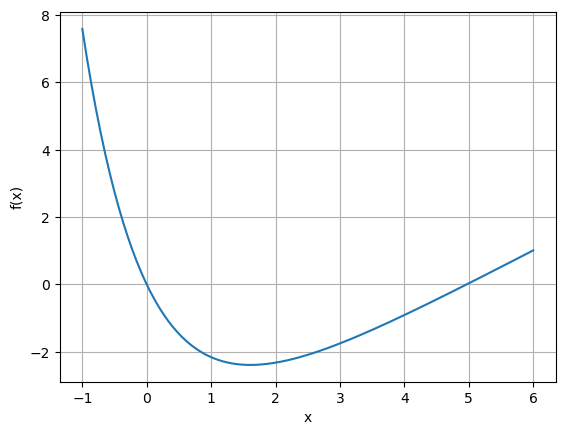

In [31]:
# part 2
# create a graph of f(x)
# create an x array
# i started from -10 to 10 and had to zoom in to see whats going on near y=0
x = np.linspace(-1, 6, 200)
# variable y is just the function at x
y = f(x)

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.show()

In [33]:
# part 2 cont.
# looks like a non zero root arount x = 5, so ill do 3 to 7
print(binary_solve(f, 3, 7, 1e-8))

4.9651142321527


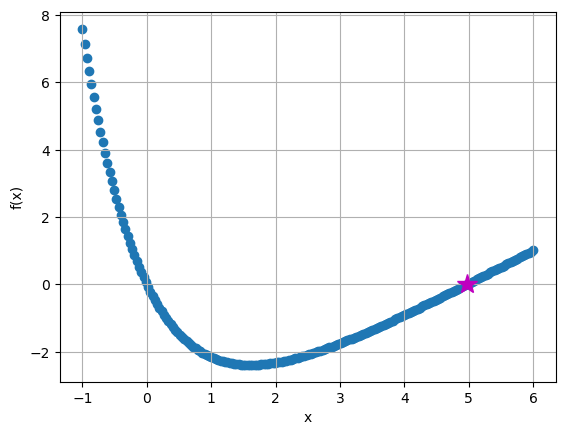

In [37]:
# part 3
# same plot as part 2
# make the star position
star = binary_solve(f, 4, 5, 1e-8)


plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
# add magenta star
plt.plot(star, f(star), 'm*', markersize=15)
plt.show()

## Energy of an electron in a square potential well

Consider a square potential well of width $w$, with walls of height $V$: 

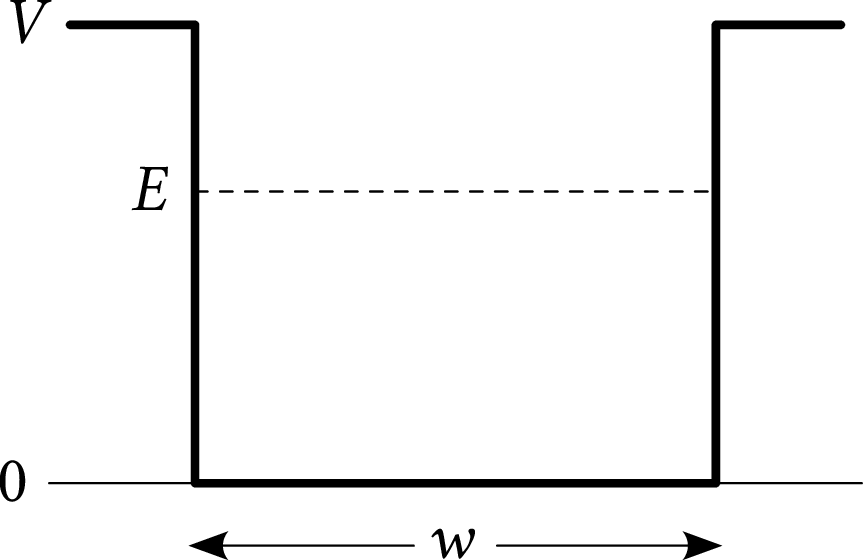

Using Schrödinger's equation, it can be shown that the allowed energies $E$ of a single quantum particle of mass $m$ trapped in the well are solutions of 
$$ \tan{\sqrt{w^2mE/2\hbar^2}} = \begin{cases} 
\sqrt{(V-E)/E} & \text{ for the even numbered states} \\
-\sqrt{E/(V-E)} & \text{ for the odd numbered states} 
\end{cases}
$$

where the states are labeled with integers starting from 0 and working upward, the ground state being state 0, the first excited state being state 1, and so forth. 

a) For an electron of (mass $9.1094 \times 10^{-31}$ kg) in a well with $V = 20 \text{ eV}$ and $w = 1 \text{ nm}$, write a Python program to plot the three quantities 
$$y_1 = \tan{\sqrt{w^2mE/2\hbar^2}} \hspace{0.2in} y_2 = \sqrt{\frac{V-E}{E}} \hspace{0.2in} y_2 = -\sqrt{\frac{E}{V-E}}, $$

on the same graph, as a function of $E$ from $E = 0$ to $E = 20 \text{ eV}$. **Hint** You may find it useful to define functions to calculate $y_1$, $y_2$, and $y_3$. 

b) From your plot make approximate estimates of the energies of the first six energy levels of the particle. 

c) Write a program to calculate the values of the first six energy levels in electron volts to an accuracy of $0.001 \text{ eV}$ using binary search. 

*hint, remember that energies need to be converted to joules in the $y_1$ equation above*

*You must clearly comment your code and include a markdown cell explaining your process*

/tmp/ipykernel_575/3647899499.py:13: RuntimeWarning: divide by zero encountered in divide
  return np.sqrt((V - E)/E)
/tmp/ipykernel_575/3647899499.py:16: RuntimeWarning: divide by zero encountered in divide
  return -np.sqrt(E/(V - E))


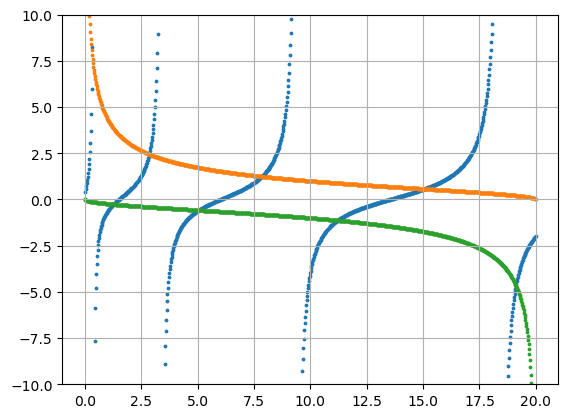

In [63]:
#a) 
# define all of the constants and things (V, w, hbar, me)
me = 9.1094e-31
V = 20 # converted to joules
hbar = 1.054e-34
w = 1e-9
                                        
# define three functions
def y1(E):
    return np.tan(np.sqrt(w**2 * me * E * 1.602e-19 / (2 * hbar**2)))

def y2(E):
    return np.sqrt((V - E)/E)

def y3(E):
    return -np.sqrt(E/(V - E))

# create an array of E's 
E = np.linspace(0, V, 1000)

# create an array for each equation using the E array

Y1 = y1(E)
Y2 = y2(E)
Y3 = y3(E)

# plot Y1 2 and 3 over E
plt.ylim(-10, 10)
plt.scatter(E, Y1, s=3)
plt.scatter(E, Y2, s=3)
plt.scatter(E, Y3, s=3)
plt.grid()

Ill just go through now and look at possible intervals of each intersection

0<I1<1.2

1.2<I2<2.5

2.5<I3<3

3<I4<5.1

5.1<I5<8.5

8.5<I6<12.5

In [66]:
#c) 
# Define the functions for even and odd states

def Y_even(E):
    return np.tan(np.sqrt(w**2 * me * E / (2 * hbar**2))) \
           - np.sqrt((V - E)/E)

def Y_odd(E):
    return np.tan(np.sqrt(w**2 * me * E / (2 * hbar**2))) \
           + np.sqrt(E/(V - E))



# define the binary solve function for just odds
def binary_solve(x1, x2, f, accuracy):
    f1 = f(x1)
    f2 = f(x2)

    if f1*f2 < 0:
        while np.abs(x2-x1) > accuracy:
            mid = (x1+x2) / 2
            fmid = f(mid)
            if fmid*f1 > 0:
                x1, f1 = mid, fmid
            else:
                x2, f2 = mid, fmid
        result = 0.5*(x1+x2)
    else:
        result = -999.99

    return result

# Plug the intervals in for the right (odd or even) function for each itersection and print result
print("I1 is located at", binary_solve(0.001, 1.2, Y_odd, 0.0001))
print("I2 is located at", binary_solve(1.2, 2.5, Y_even, 0.0001))
print("I3 is located at", binary_solve(2.5, 3, Y_odd, 0.0001))
print("I4 is located at", binary_solve(3, 5.1, Y_even, 0.0001))
print("I5 is located at", binary_solve(5.1, 8.5, Y_odd, 0.0001))
print("I6 is located at", binary_solve(8.5, 12.5, Y_even, 0.0001))



I1 is located at -999.99
I2 is located at -999.99
I3 is located at -999.99
I4 is located at -999.99
I5 is located at 5.993190002441405
I6 is located at 11.926727294921875


I am done with this for today as it is past 3:50.